# Reconocimiento de Dígitos Escritos a Mano con CNN

**Diplomado Superior en Redes Neuronales Artificiales y Deep Learning (UAEM)**  
**Módulo 4: Deep Learning | Proyecto: Reconocimiento_Dígitos**

---

## ¿Qué estamos construyendo?

Una **Red Neuronal Convolucional (CNN)** que reconozca dígitos
escritos a mano (0-9), usando el dataset más clásico de Deep
Learning: **MNIST**.

Es como enseñarle a alguien a leer números a mano: primero
necesita ver MILES de ejemplos de cada dígito, escritos por
personas distintas, con distinto trazo, para aprender qué hace
que un "7" sea un "7" y no un "1" con rayita.

Aquí construimos la CNN **desde cero** (sin Transfer Learning):
vamos a ver paso a paso cómo se forma una red convolucional,
capa por capa.

### ¿Qué aprenderás?

1. Cómo funciona una CNN por dentro (convoluciones, pooling, BatchNorm).
2. Cómo entrenar una red desde cero (sin pesos pre-entrenados).
3. Cómo evaluar con matriz de confusión (¿qué dígitos se confunden entre sí?).
4. Cómo usar el modelo con imágenes propias, incluso dibujadas a mano.


---
## 1. Configuración inicial

### ¿Qué pasa aquí?

Esta celda detecta automáticamente si estamos en **Google Colab** o
en **VSCode local** y ajusta:
- Las rutas de archivos (Drive vs local).
- El método para cargar/dibujar imágenes.
- El dispositivo de cómputo (GPU si está disponible, si no CPU).

> Así el notebook se adapta solo, sin tener que ir cambiando rutas
> a mano cada vez que cambiamos de máquina.


In [4]:
# ---
# 1. CONFIGURACION INICIAL - IMPORTS + DETECCION DE PLATAFORMA
# ---
import time
import sys, io, warnings
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
plt.ion()  # Modo interactivo para matplotlib

# Detección de plataforma: Google Colab vs Local (VSCode/Jupyter)
EN_COLAB = 'google.colab' in sys.modules

if EN_COLAB:
    print("Plataforma: Google Colab")
    from google.colab import files
    from IPython.display import display, Javascript
    from google.colab.output import eval_js
    from base64 import b64decode

    from google.colab import drive
    drive.mount('/content/drive')

    RUTA_BASE     = '/content/drive/MyDrive/Diplomado/Modulo4/Proyectos/Reconocimiento_Digitos'
    RUTA_DATOS    = RUTA_BASE + '/datos'
    RUTA_MODELOS  = RUTA_BASE + '/modelos'
    RUTA_IMAGENES = RUTA_BASE + '/imagenes_prueba'
else:
    print("Plataforma: Local (VSCode / Jupyter)")
    RUTA_BASE     = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
    RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
    RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
    RUTA_IMAGENES = os.path.join(RUTA_BASE, 'imagenes_prueba')

# Crear carpetas si no existen
for ruta in [RUTA_DATOS, RUTA_MODELOS, RUTA_IMAGENES]:
    os.makedirs(ruta, exist_ok=True)

# Dispositivo: GPU si está disponible, si no CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Dispositivo: " + str(device))
print("Ruta datos: " + RUTA_DATOS)

# --- Autoria y timer (se usa en el footer) ---
AUTORA = "Diana Blanco - MorritaConP1to"
INICIO = time.time()

Plataforma: Local (VSCode / Jupyter)
Dispositivo: cuda
Ruta datos: d:\Diplomado-RNA\Modulo-4\Proyectos\Reconocimiento_Digitos\datos


---
## 2. Carga del Dataset MNIST

**MNIST** (Modified National Institute of Standards and Technology):
- **60,000 imágenes** de entrenamiento, **10,000** de prueba.
- Cada imagen: **28x28 píxeles**, **escala de grises**, dígito centrado.
- **10 clases**: dígitos del 0 al 9.

> Es básicamente el "Hola Mundo" de Deep Learning con imágenes:
> casi todo mundo que aprende redes neuronales pasa por aquí primero.

### Preprocesamiento

1. `ToTensor()`: convierte [0, 255] a [0.0, 1.0] y reordena a (canal, alto, ancho).
2. `Normalize(0.1307, 0.3081)`: son la media y desviación estándar
   reales de TODO el dataset MNIST (valores ya calculados por la
   comunidad, no hay que recalcularlos).


In [5]:
# ---
# 2. CARGA DEL DATASET MNIST
# ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root=RUTA_DATOS, train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root=RUTA_DATOS, train=False, download=True, transform=transform
)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("MNIST cargado: " + str(len(train_dataset)) + " train + " + str(len(test_dataset)) + " test")
print("Lotes de " + str(BATCH_SIZE) + " imágenes -> " + str(len(train_loader)) + " lotes/época")

MNIST cargado: 60000 train + 10000 test
Lotes de 64 imágenes -> 938 lotes/época


---
## 3. Definición de la Arquitectura CNN

Usamos **3 capas convolucionales** con el patrón: Conv + BatchNorm + ReLU + MaxPool.

### ¿Por qué BatchNorm?
Normaliza la salida de cada capa para que el gradiente fluya estable. Permite:
- Mayor tasa de aprendizaje.
- Menos sensibilidad a la inicialización.
- Efecto regularizador leve.

### ¿Por qué Dropout?
Apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento
para que la red no dependa de unas pocas neuronas "estrella"


In [6]:
# ---
# 3. ARQUITECTURA DE LA CNN
# ---
class CNNMejorada(nn.Module):
    '''
    CNN para clasificación de dígitos MNIST (10 clases).

    Arquitectura:
      Bloque 1: Conv(1->32, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
      Bloque 2: Conv(32->64, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
      Bloque 3: Conv(64->128, 3x3) + BatchNorm + ReLU + MaxPool(2x2)
      Dropout(0.3) + FC(1152->256) + ReLU + Dropout(0.3) + FC(256->10)

    La entrada esperada es [batch, 1, 28, 28] (escala de grises).
    La salida son logits (sin softmax) para 10 clases.

    Ejemplo:
        model = CNNMejorada()
        x = torch.randn(4, 1, 28, 28)  # batch de 4 imágenes
        out = model(x)  # -> [4, 10]
    '''

    def __init__(self):
        super(CNNMejorada, self).__init__()

        # Bloque convolucional 1: detecta bordes, curvas, líneas simples
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Bloque convolucional 2: detecta patrones intermedios (esquinas, circulos)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Bloque convolucional 3: detecta formas completas de dígitos
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # MaxPool: reduce dimensión espacial a la mitad
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout: regularización para evitar sobreajuste
        self.dropout = nn.Dropout(0.3)

        # Clasificador (capas densas / fully connected)
        # Despues de 3 MaxPool: 28x28 -> 14x14 -> 7x7 -> 3x3
        # Total features: 128 canales * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Bloque 1: 28x28 -> 14x14
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        # Bloque 2: 14x14 -> 7x7
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        # Bloque 3: 7x7 -> 3x3
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        # Aplanar: [batch, 128, 3, 3] -> [batch, 1152]
        x = x.view(x.size(0), -1)

        # Clasificador con dropout intermedio
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)  # Logits crudos, sin softmax

        return x

# Instanciar el modelo
model = CNNMejorada().to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Modelo CNNMejorada creado")
print("Parametros totales: " + str(total_params))
print("Parametros entrenables: " + str(trainable_params))

Modelo CNNMejorada creado
Parametros totales: 390858
Parametros entrenables: 390858


---
## 4. Configuración del Entrenamiento

| Componente | Elección | Por qué |
|-----------|----------|---------|
| **Loss** | CrossEntropyLoss | Ideal para clasificación multiclase. Combina softmax + entropía cruzada |
| **Optimizer** | Adam | Tasa de aprendizaje adaptativa, converge rápido sin ajuste fino |
| **LR inicial** | 0.001 | Valor estándar para Adam |
| **ReduceLROnPlateau** | Paciencia=3 | Si la pérdida se estanca, reduce la LR para afinar |
| **Early Stopping** | Paciencia=5 | Detiene el entrenamiento si no hay mejora, evita sobreajuste |


In [7]:
# ---
# 4. FUNCION DE PERDIDA, OPTIMIZADOR Y CALLBACKS
# ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ReduceLROnPlateau: reduce la tasa de aprendizaje cuando la pérdida se estanca
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

print("Configuración lista:")
print("  Loss: CrossEntropyLoss")
print("  Optimizer: Adam (lr=0.001)")
print("  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

Configuración lista:
  Loss: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


---
## 5. Entrenamiento del Modelo

### Flujo por cada lote (batch)

```
imágenes --> CNN --> predicciones --> loss --> backward --> optimizer.step()
                        |
                etiquetas reales
```

### Early Stopping
Si la pérdida de validación no mejora en 5 épocas consecutivas, el
entrenamiento se detiene. Esto evita que la red memorice los datos
de entrenamiento (overfitting) — como cuando te aprendes las
respuestas de un examen de práctica de memoria, en vez de entender
el tema: te va perfecto en ESE examen, pero te estrellas en el real.

### ReduceLROnPlateau
Si la pérdida se estanca por 3 épocas, la tasa de aprendizaje se
reduce a la mitad para hacer descensos más finos, en vez de quedarnos
pegados sin avanzar.


In [8]:
# ---
# 5. BUCLE DE ENTRENAMIENTO
# ---
def entrenar(modelo, train_loader, test_loader, criterion, optimizer,
             scheduler, num_epochs=40, paciencia_early=5):
    '''
    Bucle de entrenamiento con Early Stopping y ReduceLROnPlateau.

    Args:
        modelo: Red neuronal (subclase de nn.Module).
        train_loader: DataLoader con datos de entrenamiento.
        test_loader: DataLoader con datos de validación/prueba.
        criterion: Función de pérdida (CrossEntropyLoss).
        optimizer: Optimizador (Adam).
        scheduler: ReduceLROnPlateau para ajustar LR dinamicamente.
        num_epochs: Maximo de épocas a entrenar.
        paciencia_early: Epocas sin mejora antes de detener.

    Returns:
        historial: dict con train_loss y test_acc por época para graficar.

    Ejemplo:
        hist = entrenar(modelo, train_loader, test_loader, criterion, optimizer, scheduler)
    '''
    historial = {'train_loss': [], 'test_acc': []}
    mejor_loss = float('inf')
    epocas_sin_mejora = 0

    for epoch in range(num_epochs):
        # ---- Entrenamiento ----
        modelo.train()
        loss_acumulada = 0.0

        for imágenes, etiquetas in train_loader:
            imágenes, etiquetas = imágenes.to(device), etiquetas.to(device)

            optimizer.zero_grad()
            predicciones = modelo(imágenes)
            loss = criterion(predicciones, etiquetas)
            loss.backward()
            optimizer.step()

            loss_acumulada += loss.item()

        loss_promedio = loss_acumulada / len(train_loader)
        historial['train_loss'].append(loss_promedio)

        # ---- Evaluación en test ----
        modelo.eval()
        correctos = 0
        total = 0
        with torch.no_grad():
            for imágenes, etiquetas in test_loader:
                imágenes, etiquetas = imágenes.to(device), etiquetas.to(device)
                outputs = modelo(imágenes)
                _, predichos = torch.max(outputs.data, 1)
                total += etiquetas.size(0)
                correctos += (predichos == etiquetas).sum().item()

        accuracy = 100.0 * correctos / total
        historial['test_acc'].append(accuracy)

        lr_actual = optimizer.param_groups[0]['lr']
        print('Epoca [{:2d}/{}]  Loss: {:.4f}  Accuracy test: {:.2f}%  LR: {:.6f}'.format(
            epoch+1, num_epochs, loss_promedio, accuracy, lr_actual))

        # Scheduler: ReduceLROnPlateau
        scheduler.step(loss_promedio)

        # Early Stopping
        if loss_promedio < mejor_loss:
            mejor_loss = loss_promedio
            epocas_sin_mejora = 0
            # Guardar el mejor modelo encontrado
            torch.save(modelo.state_dict(), os.path.join(RUTA_MODELOS, 'mejor_modelo.pth'))
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= paciencia_early:
                print('Early stopping activado tras {} épocas sin mejora.'.format(epoch+1))
                break

    print('\nEntrenamiento completado. Mejor accuracy: {:.2f}%'.format(max(historial['test_acc'])))
    return historial


# Ejecutar entrenamiento
num_epochs = 40
historial = entrenar(model, train_loader, test_loader, criterion, optimizer,
                     scheduler, num_epochs=num_epochs, paciencia_early=5)

Epoca [ 1/40]  Loss: 0.1171  Accuracy test: 98.89%  LR: 0.001000
Epoca [ 2/40]  Loss: 0.0456  Accuracy test: 98.92%  LR: 0.001000
Epoca [ 3/40]  Loss: 0.0330  Accuracy test: 99.14%  LR: 0.001000
Epoca [ 4/40]  Loss: 0.0282  Accuracy test: 99.22%  LR: 0.001000
Epoca [ 5/40]  Loss: 0.0219  Accuracy test: 99.31%  LR: 0.001000
Epoca [ 6/40]  Loss: 0.0187  Accuracy test: 99.28%  LR: 0.001000
Epoca [ 7/40]  Loss: 0.0149  Accuracy test: 99.19%  LR: 0.001000
Epoca [ 8/40]  Loss: 0.0126  Accuracy test: 99.10%  LR: 0.001000
Epoca [ 9/40]  Loss: 0.0117  Accuracy test: 99.16%  LR: 0.001000
Epoca [10/40]  Loss: 0.0114  Accuracy test: 99.13%  LR: 0.001000
Epoca [11/40]  Loss: 0.0089  Accuracy test: 99.22%  LR: 0.001000
Epoca [12/40]  Loss: 0.0074  Accuracy test: 99.39%  LR: 0.001000
Epoca [13/40]  Loss: 0.0093  Accuracy test: 99.33%  LR: 0.001000
Epoca [14/40]  Loss: 0.0066  Accuracy test: 99.03%  LR: 0.001000
Epoca [15/40]  Loss: 0.0073  Accuracy test: 99.37%  LR: 0.001000
Epoca [16/40]  Loss: 0.00

---
## 6. Visualización del Progreso

- **Gráfica izquierda**: la pérdida (loss) disminuye época tras época. Una curva suave y descendente indica entrenamiento saludable.
- **Gráfica derecha**: la precisión (accuracy) en el conjunto de prueba mejora.

Si la pérdida de entrenamiento sigue bajando pero la de prueba sube -> **sobreajuste (overfitting)**.


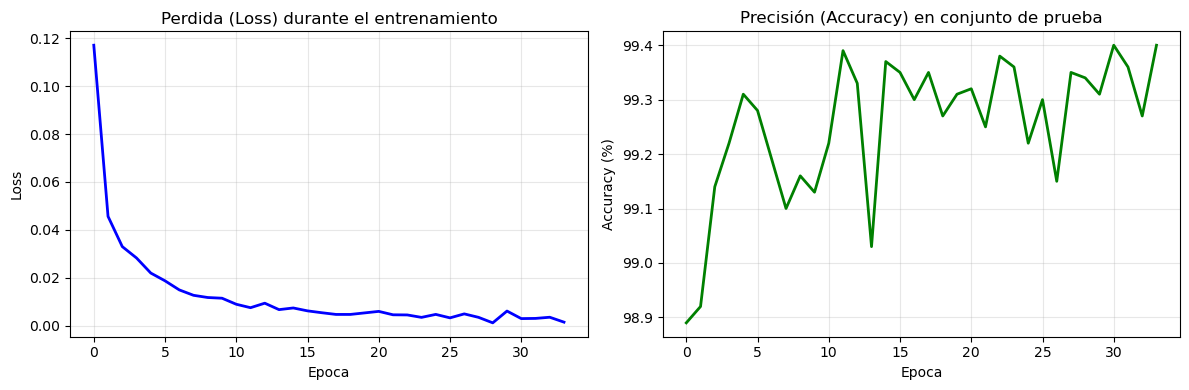

Mejor accuracy en test: 99.40%


In [9]:
# ---
# 6. GRAFICA DE EVOLUCION DEL ENTRENAMIENTO
# ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historial['train_loss'], 'b-', linewidth=2)
ax1.set_title('Perdida (Loss) durante el entrenamiento')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(historial['test_acc'], 'g-', linewidth=2)
ax2.set_title('Precisión (Accuracy) en conjunto de prueba')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Mejor accuracy en test: {:.2f}%'.format(max(historial['test_acc'])))

---
## 7. Evaluación Detallada

La **matriz de confusión** muestra qué dígitos confunde el modelo entre sí.
- **Diagonal**: aciertos (predicción correcta).
- **Fuera de diagonal**: errores.

> Piénsalo como el reporte de daños después de un combo en un
> fighting game: no solo te dice cuánto daño hiciste en total
> (eso ya lo sabíamos por el accuracy), te dice CONTRA QUÉ
> personaje en específico te está costando ganar.

Si el modelo confunde 4 con 9 frecuentemente, sabremos que necesita
más ejemplos de esos dígitos.


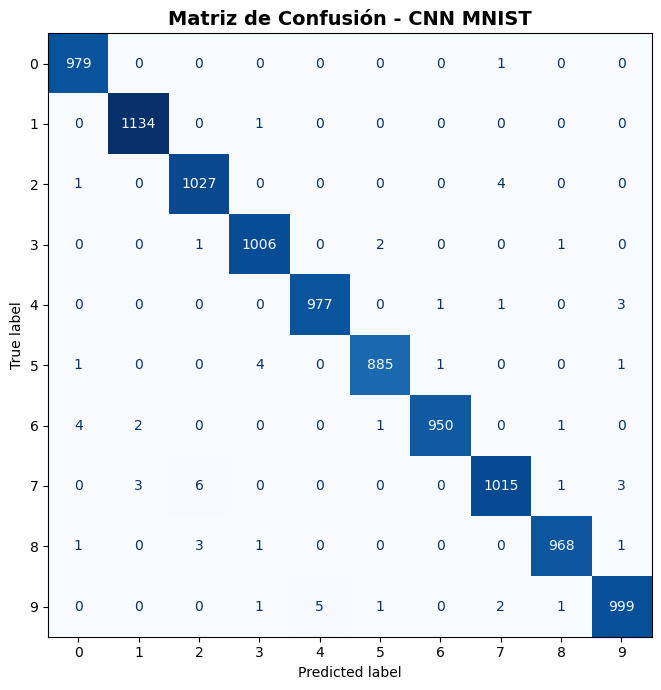

Accuracy global en test: 99.40%

Confusiones más frecuentes:
  * 7 confundido con 2: 6 veces


In [10]:
# ---
# 7. MATRIZ DE CONFUSION
# ---
def evaluar_matriz_confusión(modelo, test_loader, device):
    '''
    Calcula y muestra la matriz de confusión en el conjunto de prueba.

    Args:
        modelo: Modelo entrenado.
        test_loader: DataLoader con datos de prueba.
        device: Dispositivo (CPU/GPU).

    Ejemplo:
        evaluar_matriz_confusión(model, test_loader, device)
    '''
    modelo.eval()
    todas_reales = []
    todas_predichas = []

    with torch.no_grad():
        for imágenes, etiquetas in test_loader:
            imágenes = imágenes.to(device)
            outputs = modelo(imágenes)
            _, predichas = torch.max(outputs, 1)

            todas_reales.extend(etiquetas.cpu().numpy())
            todas_predichas.extend(predichas.cpu().numpy())

    # Calcular matriz
    cm = confusion_matrix(todas_reales, todas_predichas)

    # Graficar
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')

    ax.set_title('Matriz de Confusión - CNN MNIST', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Accuracy final
    accuracy = 100.0 * np.trace(cm) / np.sum(cm)
    print('Accuracy global en test: {:.2f}%'.format(accuracy))

    # Mostrar confusiones más frecuentes
    print('\nConfusiones más frecuentes:')
    for i in range(10):
        for j in range(10):
            if i != j and cm[i][j] > 5:  # Mas de 5 errores
                print('  * {} confundido con {}: {} veces'.format(i, j, int(cm[i][j])))


evaluar_matriz_confusión(model, test_loader, device)

---
## 8. Ejemplos de Aciertos y Errores

Ver ejemplos concretos ayuda a entender **qué está aprendiendo la red**:
las métricas dicen CUÁNTO acierta, pero no te dicen POR QUÉ falla.
Para eso hay que ver las imágenes con tus propios ojos.

- ¿Los errores son comprensibles (un 7 que parece 1)?
- ¿O la red falla en casos obvios?


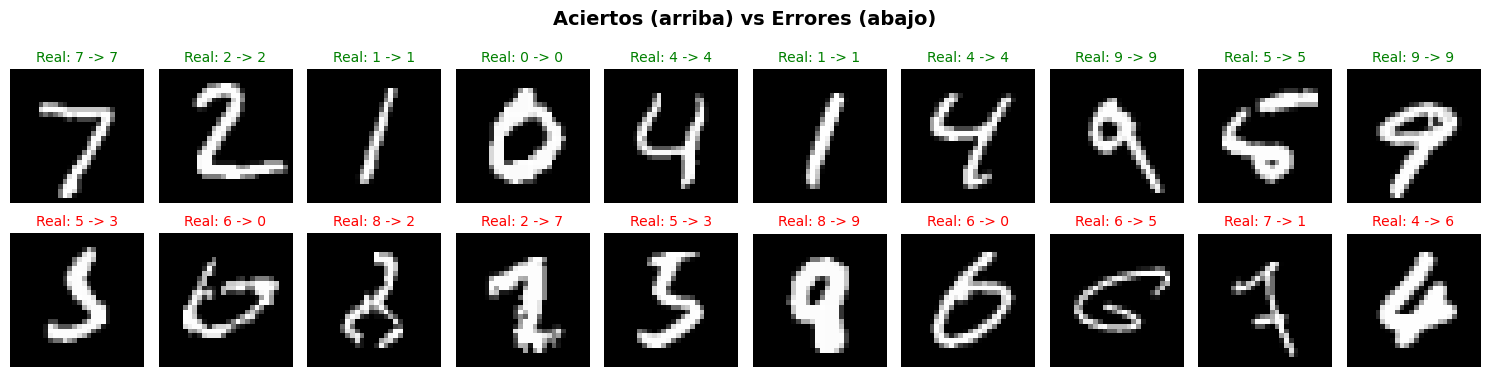

In [11]:
# ---
# 8. MUESTRA DE ACIERTOS Y ERRORES
# ---
def mostrar_ejemplos(modelo, test_loader, device, num_ejemplos=10):
    '''
    Muestra ejemplos de predicciones correctas e incorrectas.

    Args:
        modelo: Modelo entrenado.
        test_loader: DataLoader con datos de prueba.
        device: Dispositivo.
        num_ejemplos: Cuántos ejemplos mostrar por categoria (default 10).

    Ejemplo:
        mostrar_ejemplos(model, test_loader, device)
    '''
    modelo.eval()
    correctos = []
    incorrectos = []

    with torch.no_grad():
        for imágenes, etiquetas in test_loader:
            imagenes_gpu = imágenes.to(device)
            outputs = modelo(imagenes_gpu)
            _, predichas = torch.max(outputs, 1)

            for i in range(len(etiquetas)):
                par = (imágenes[i].cpu(), etiquetas[i].item(), predichas[i].item())
                if predichas[i] == etiquetas[i] and len(correctos) < num_ejemplos:
                    correctos.append(par)
                elif predichas[i] != etiquetas[i] and len(incorrectos) < num_ejemplos:
                    incorrectos.append(par)

            if len(correctos) >= num_ejemplos and len(incorrectos) >= num_ejemplos:
                break

    # Graficar
    fig, axes = plt.subplots(2, num_ejemplos, figsize=(15, 4))
    fig.suptitle('Aciertos (arriba) vs Errores (abajo)', fontsize=14, fontweight='bold')

    for i, (img, real, pred) in enumerate(correctos):
        axes[0, i].imshow(img.squeeze(), cmap='gray')
        axes[0, i].set_title('Real: {} -> {}'.format(real, pred), color='green', fontsize=10)
        axes[0, i].axis('off')

    for i, (img, real, pred) in enumerate(incorrectos):
        axes[1, i].imshow(img.squeeze(), cmap='gray')
        axes[1, i].set_title('Real: {} -> {}'.format(real, pred), color='red', fontsize=10)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


mostrar_ejemplos(model, test_loader, device)

---
## 9. Inferencia en Imágenes Externas

El modelo fue entrenado con **MNIST**: dígitos blancos sobre fondo negro, centrados, 28x28, escala de grises.
Para que funcione con imágenes reales (fotos, capturas, dibujos), debemos preprocesarlas.

### Pipeline de preprocesamiento

```
Imagen original (cualquier tamaño/color)
  |
  1. Escala de grises (1 canal)
  |
  2. Binarización (umbral adaptativo) para fondo limpio
  |
  3. Recorte del dígito con bounding box
  |
  4. Redimensionar manteniendo aspecto -> 20px el lado más grande
  |
  5. Centrar en lienzo 28x28 (como MNIST original)
  |
  6. Invertir si fondo es claro (MNIST = blanco sobre negro)
  |
  7. Normalizar con media/desviación de MNIST
  |
  Tensor [1, 1, 28, 28] listo para el modelo
```


In [12]:
# ---
# 9. PREPROCESAMIENTO DE IMAGENES EXTERNAS
# ---
def preprocesar_para_mnist(imagen_pil):
    '''
    Convierte cualquier imagen al formato que espera la CNN de MNIST.

    El pipeline replica las condiciones del dataset original:
      1. Escala de grises.
      2. Binarización con umbral adaptativo.
      3. Recorte del dígito (bounding box) con margen.
      4. Redimensionado a 20x20 preservando aspecto.
      5. Centrado en lienzo 28x28.
      6. Inversión si fondo es claro (MNIST = blanco sobre negro).
      7. Normalización con estadisticas de MNIST.

    Args:
        imagen_pil (PIL.Image): Imagen en cualquier formato/color/tamaño.

    Returns:
        tuple: (tensor_listo, arreglo_28x28)
            tensor_listo  -> torch.Tensor [1, 1, 28, 28] para el modelo
            arreglo_28x28 -> np.ndarray [28, 28] para visualización

    Ejemplo:
        img = Image.open('mi_numero.jpg')
        tensor, arr = preprocesar_para_mnist(img)
        predicción = model(tensor)
    '''
    # 1. Escala de grises
    gris = imagen_pil.convert('L')

    # Redimensionar a tamaño intermedio para mejor manejo
    gris = gris.resize((100, 100))

    # Convertir a array para procesamiento numerico
    arr = np.array(gris, dtype=np.float32)

    # 2. Invertir si el fondo es más claro que el dígito
    #    MNIST tiene dígito claro sobre fondo oscuro
    if arr.mean() > 127:
        arr = 255.0 - arr

    # 3. Binarizar con umbral adaptativo
    umbral = arr.mean() * 1.2
    arr[arr < umbral] = 0.0
    arr[arr >= umbral] = 255.0

    # 4. Encontrar bounding box del dígito (pixeles no negros)
    filas_con_digito = np.where(np.any(arr > 0, axis=1))[0]
    cols_con_digito = np.where(np.any(arr > 0, axis=0))[0]

    if len(filas_con_digito) == 0 or len(cols_con_digito) == 0:
        # No se encontro dígito: devolver lienzo vacio
        arr_28 = np.zeros((28, 28), dtype=np.float32)
        tensor = torch.from_numpy(arr_28).unsqueeze(0).unsqueeze(0)
        return tensor, arr_28

    y_min, y_max = filas_con_digito[0], filas_con_digito[-1]
    x_min, x_max = cols_con_digito[0], cols_con_digito[-1]

    # 5. Recortar el dígito con margen
    margen = 5
    y_min = max(0, y_min - margen)
    y_max = min(arr.shape[0], y_max + margen)
    x_min = max(0, x_min - margen)
    x_max = min(arr.shape[1], x_max + margen)
    recorte = arr[y_min:y_max+1, x_min:x_max+1]

    # 6. Redimensionar manteniendo aspecto -> 20px el lado más grande
    alto, ancho = recorte.shape
    escala = 20.0 / max(alto, ancho)
    nuevo_alto = max(1, int(alto * escala))
    nuevo_ancho = max(1, int(ancho * escala))

    recorte_20 = np.array(
        Image.fromarray(recorte).resize((nuevo_ancho, nuevo_alto)),
        dtype=np.float32
    )

    # 7. Centrar en lienzo 28x28 (como en MNIST original)
    arr_28 = np.zeros((28, 28), dtype=np.float32)
    y_offset = (28 - nuevo_alto) // 2
    x_offset = (28 - nuevo_ancho) // 2
    arr_28[y_offset:y_offset+nuevo_alto, x_offset:x_offset+nuevo_ancho] = recorte_20

    # 8. Normalizar con media/desviación de MNIST
    arr_28 = arr_28 / 255.0  # [0, 1]
    arr_28 = (arr_28 - 0.1307) / 0.3081

    # 9. Convertir a tensor [1, 1, 28, 28]
    tensor = torch.from_numpy(arr_28).float().unsqueeze(0).unsqueeze(0)

    # La imagen para mostrar necesita estar en [0, 1] sin normalizar
    arr_mostrar = (arr_28 * 0.3081 + 0.1307).clip(0, 1)

    return tensor, arr_mostrar

---
## 10. Función de Predicción

Toma una imagen PIL, la preprocesa, la pasa por el modelo y muestra:
1. La imagen tal como la 've' el modelo (28x28 centrada, en grises).
2. El dígito predicho y su nivel de confianza.
3. (Opcional) Gráfico de barras con la probabilidad para cada dígito.


In [13]:
# ---
# 10. PREDICCION CON VISUALIZACION
# ---
def predecir_numero(imagen_pil, modelo, device, mostrar_probabilidades=True):
    '''
    Predice el dígito en una imagen y muestra resultados visuales.

    Flujo:
        Imagen PIL -> preprocesar_para_mnist() -> CNN -> softmax -> predicción

    Args:
        imagen_pil (PIL.Image): Imagen de entrada.
        modelo (nn.Module): Modelo entrenado.
        device (torch.device): Dispositivo de cómputo.
        mostrar_probabilidades (bool): Si True, muestra grafico de barras.

    Returns:
        int: Dígito predicho (0-9).

    Ejemplo:
        resultado = predecir_numero(Image.open('test.jpg'), model, device)
        print('Predicción:', resultado)
    '''
    tensor_imagen, imagen_28x28 = preprocesar_para_mnist(imagen_pil)
    tensor_imagen = tensor_imagen.to(device)

    modelo.eval()
    with torch.no_grad():
        salida = modelo(tensor_imagen)
        probabilidades = torch.softmax(salida, dim=1)
        _, predicción = torch.max(salida, 1)

    numero_predicho = predicción.item()
    confianza = probabilidades[0][numero_predicho].item() * 100

    # ---- Visualización ----
    if mostrar_probabilidades:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig, ax1 = plt.subplots(figsize=(4, 4))

    # Imagen preprocesada (como la ve el modelo)
    ax1.imshow(imagen_28x28, cmap='gray')
    ax1.set_title('Predicción: {}\n(Confianza: {:.1f}%)'.format(numero_predicho, confianza),
                  fontsize=12, fontweight='bold')
    ax1.axis('off')

    if mostrar_probabilidades:
        prob_np = probabilidades[0].cpu().numpy()
        colores = ['steelblue'] * 10
        colores[numero_predicho] = 'crimson'  # Destacar el elegido
        ax2.bar(range(10), prob_np, color=colores, edgecolor='gray')
        ax2.set_xticks(range(10))
        ax2.set_xlabel('Dígito')
        ax2.set_ylabel('Probabilidad')
        ax2.set_title('Distribución de probabilidad por dígito')
        ax2.set_ylim(0, 1)
        ax2.grid(axis='y', alpha=0.3)

        # Etiqueta con el valor exacto
        for i, v in enumerate(prob_np):
            if v > 0.05:
                ax2.text(i, v + 0.02, '{:.1%}'.format(v), ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    return numero_predicho

---
## 11. Probar el Modelo con tus Propias Imágenes

Aquí está la parte divertida: ahora le toca a TU letra. Vamos a ver
si el modelo entiende tu manera de escribir los números igual que
entiende los del dataset.

### Tips para mejores resultados
- El número debe ocupar la mayor parte de la imagen.
- Fondo simple (hoja blanca, pizarrón).
- Trazos gruesos y claros.
- Evitar sombras y reflejos.

### Opciones disponibles
- **Opción A**: Subir una foto de un número escrito a mano.
- **Opción B**: Dibujar un número con el mouse.


### Opción A: Subir una imagen

In [ ]:
# ---
# 11a. SUBIR IMAGEN (Google Colab)
# ---
if EN_COLAB:
    print('Sube una imagen con un número escrito a mano (0-9)...')
    archivos_subidos = files.upload()

    if archivos_subidos:
        nombre = list(archivos_subidos.keys())[0]
        imagen = Image.open(io.BytesIO(archivos_subidos[nombre]))
        print('Procesando: ' + nombre)
        predecir_numero(imagen, model, device)
    else:
        print('No se subio ningún archivo.')
else:
    print('Ejecuta la siguiente celda (VSCode).')

Ejecuta la siguiente celda (VSCode).


: 

In [ ]:
# ---
# 11a. SUBIR IMAGEN (VSCode) - selector de archivos nativo
# ---
if not EN_COLAB:
    from tkinter import filedialog, Tk
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    ruta = filedialog.askopenfilename(
        title='Selecciona una imagen de un dígito',
        filetypes=[('Imágenes', '*.png *.jpg *.jpeg *.bmp *.tiff')]
    )

    if ruta:
        print('Abriendo: ' + ruta)
        imagen = Image.open(ruta)
        predecir_numero(imagen, model, device)
    else:
        print('No se selecciono ningún archivo.')
else:
    print('Usa la celda anterior (Colab) para subir archivos.')

### Opción B: Dibujar el número con el mouse

In [ ]:
# ---
# 11b. DIBUJAR NUMERO (Google Colab) - canvas interactivo en el navegador
# ---
if EN_COLAB:
    def dibujar_numero_colab():
        '''
        Muestra un canvas en el navegador para dibujar con el mouse.
        Al presionar 'Predecir', la imagen se envia a Python.

        El canvas es de 280x280 (10x el tamaño MNIST para mejor
        resolución de dibujo), luego se redimensiona internamente.

        Returns:
            PIL.Image: La imagen dibujada.
        '''
        codigo_js = '''
        async function dibujarNumero() {
            const canvas = document.createElement('canvas');
            canvas.width = 280;
            canvas.height = 280;
            canvas.style.border = '2px solid black';
            canvas.style.cursor = 'crosshair';

            const ctx = canvas.getContext('2d');
            ctx.fillStyle = 'black';
            ctx.fillRect(0, 0, canvas.width, canvas.height);
            ctx.strokeStyle = 'white';
            ctx.lineWidth = 18;
            ctx.lineCap = 'round';
            ctx.lineJoin = 'round';

            let dibujando = false;
            let ultimoX = 0, ultimoY = 0;

            function obtenerPos(evento) {
                const rect = canvas.getBoundingClientRect();
                return [evento.clientX - rect.left, evento.clientY - rect.top];
            }

            canvas.addEventListener('mousedown', (e) => {
                dibujando = true;
                [ultimoX, ultimoY] = obtenerPos(e);
            });
            canvas.addEventListener('mousemove', (e) => {
                if (!dibujando) return;
                const [x, y] = obtenerPos(e);
                ctx.beginPath();
                ctx.moveTo(ultimoX, ultimoY);
                ctx.lineTo(x, y);
                ctx.stroke();
                [ultimoX, ultimoY] = [x, y];
            });
            canvas.addEventListener('mouseup', () => dibujando = false);
            canvas.addEventListener('mouseleave', () => dibujando = false);

            const botonBorrar = document.createElement('button');
            botonBorrar.textContent = 'Borrar';
            botonBorrar.onclick = () => {
                ctx.fillStyle = 'black';
                ctx.fillRect(0, 0, canvas.width, canvas.height);
            };

            const botonPredecir = document.createElement('button');
            botonPredecir.textContent = 'Predecir';
            botonPredecir.style.marginLeft = '10px';

            document.body.appendChild(canvas);
            document.body.appendChild(document.createElement('br'));
            document.body.appendChild(botonBorrar);
            document.body.appendChild(botonPredecir);

            return new Promise((resolve) => {
                botonPredecir.onclick = () => {
                    resolve(canvas.toDataURL('image/png'));
                };
            });
        }
        '''
        display(Javascript(codigo_js))
        datos_imagen = eval_js('dibujarNumero()')
        encabezado, datos_codificados = datos_imagen.split(',', 1)
        bytes_imagen = b64decode(datos_codificados)
        return Image.open(io.BytesIO(bytes_imagen))

    print('Dibuja un número (0-9) en el canvas y presiona Predecir')
    imagen_dibujada = dibujar_numero_colab()
    predecir_numero(imagen_dibujada, model, device)
else:
    print('Usa la siguiente celda (VSCode) para dibujar con matplotlib.')

In [ ]:
# ---
# 11b. DIBUJAR NUMERO (VSCode) - widget interactivo con matplotlib
# ---
if not EN_COLAB:
    def dibujar_numero_vscode(tamano_lienzo=280):
        '''
        Crea una ventana interactiva con matplotlib para dibujar un
        dígito con el mouse.

        Funcionamiento:
          - Manten presionado el boton izquierdo del mouse para dibujar.
          - Al cerrar la ventana, la imagen se envia al modelo.

        Args:
            tamano_lienzo: Tamano del canvas en pixeles (default 280).

        Returns:
            PIL.Image: La imagen dibujada.
        '''
        from matplotlib.figure import Figure
        from matplotlib.backend_bases import MouseButton

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(0, tamano_lienzo)
        ax.set_ylim(0, tamano_lienzo)
        ax.set_facecolor('black')
        ax.invert_yaxis()
        ax.set_title('Dibuja un número. Cierra la ventana para predecir.', fontsize=10)
        ax.axis('off')

        from numpy import zeros, uint8
        img_arr = zeros((tamano_lienzo, tamano_lienzo), dtype=uint8)

        linea_actual = None
        puntos_x = []
        puntos_y = []

        def on_press(evento):
            nonlocal linea_actual, puntos_x, puntos_y
            if evento.inaxes != ax:
                return
            puntos_x = [evento.xdata]
            puntos_y = [evento.ydata]
            linea_actual, = ax.plot(puntos_x, puntos_y, color='white',
                                    linewidth=8, solid_capstyle='round')
            fig.canvas.draw_idle()

        def on_motion(evento):
            nonlocal puntos_x, puntos_y
            if evento.inaxes != ax or not puntos_x:
                return
            puntos_x.append(evento.xdata)
            puntos_y.append(evento.ydata)
            linea_actual.set_data(puntos_x, puntos_y)
            fig.canvas.draw_idle()

        def on_release(evento):
            nonlocal puntos_x, puntos_y
            if not puntos_x:
                return
            from skimage.draw import line as skiline
            for i in range(len(puntos_x) - 1):
                try:
                    rr, cc = skiline(int(round(puntos_y[i])), int(round(puntos_x[i])),
                                     int(round(puntos_y[i+1])), int(round(puntos_x[i+1])))
                    mascara = (rr >= 0) & (rr < tamano_lienzo) & (cc >= 0) & (cc < tamano_lienzo)
                    img_arr[rr[mascara], cc[mascara]] = 255
                except Exception:
                    pass
            puntos_x = []
            puntos_y = []

        fig.canvas.mpl_connect('button_press_event', on_press)
        fig.canvas.mpl_connect('motion_notify_event', on_motion)
        fig.canvas.mpl_connect('button_release_event', on_release)

        plt.show(block=True)

        return Image.fromarray(img_arr)

    print('Dibuja un número en la ventana y cierrala para predecir...')
    imagen_dibujada = dibujar_numero_vscode()
    resultado = predecir_numero(imagen_dibujada, model, device)
    print('Dígito predicho: ' + str(resultado))
else:
    print('Usa la celda anterior (Colab) para dibujar en el canvas.')

---
## 12. Guardar el Modelo Entrenado

El modelo se guarda en formato PyTorch (.pth) dentro de la carpeta `modelos/`.

Para cargarlo después:
```python
modelo = CNNMejorada()
modelo.load_state_dict(torch.load('modelos/modelo_digitos.pth'))
modelo.to(device)
```


In [ ]:
# ---
# 12. GUARDAR MODELO ENTRENADO
# ---
ruta_modelo = os.path.join(RUTA_MODELOS, 'modelo_digitos.pth')
torch.save(model.state_dict(), ruta_modelo)
print('Modelo guardado en: ' + ruta_modelo)
print('Tamano: {:.1f} KB'.format(os.path.getsize(ruta_modelo) / 1024.0))

In [ ]:
# ---
# 13. FOOTER DE AUTORIA Y RENDIMIENTO
# ---
import time, psutil, platform

fin = time.time()
segundos = fin - INICIO
mm, ss = divmod(int(segundos), 60)

print("")
print("=" * 55)
print("  Hecho con 💜 por " + AUTORA)
print("  Diplomado RNA - Módulo 4: Deep Learning")
print("  UAEM")
print("")
print("  Especificaciones del equipo:")
cpu = platform.processor() or "AMD Ryzen 5 3600"
print("     CPU: " + cpu)
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"
gpu_mem = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if torch.cuda.is_available() else 0
print("     GPU: " + gpu_name + " (" + str(gpu_mem) + " GB)")
ram = round(psutil.virtual_memory().total / 1e9, 1)
print("     RAM: " + str(ram) + " GB")
print("     PyTorch " + torch.__version__ + " + CUDA " + (torch.versión.cuda or "N/A"))
print("")
print("  Tiempo total de ejecución: " + str(mm) + " min " + str(ss) + " seg")
print("  Mejor accuracy en test: " + "{:.2f}%".format(max(historial['test_acc'])))
print("  Fecha: " + time.strftime('%Y-%m-%d %H:%M'))
print("=" * 55)


---
## Referencias y Recursos

- [MNIST Database](http://yann.lecun.com/exdb/mnist/) - Página oficial del dataset
- [PyTorch: CNN Tutorial](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) - Tutorial oficial
- [CS231n: CNNs for Visual Recognition](http://cs231n.github.io/convolutional-networks/) - Notas del curso de Stanford
- [Batch Normalization Paper](https://arxiv.org/abs/1502.03167) - Explicación original (Ioffe & Szegedy, 2015)
- [Repositorio del proyecto](https://github.com/MorritaConP1to/Diplomado-RNA) - Código completo del diplomado
